In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import yfinance as yf
import os
# If mplfinance is not installed, run:
# !pip install mplfinance
import mplfinance as mpf

from tensorflow.keras import mixed_precision
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM



In [2]:
# Mixed precision setting

In [3]:
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

In [4]:
## Stock selection and training period

# Here I define the stock ticker and the period used for training data.

In [5]:
COMPANY = 'CBA.AX'

TRAIN_START = '2020-01-01'
TRAIN_END = '2023-08-01'

TEST_START = '2023-08-02'
TEST_END = '2024-07-02'

In [6]:
## Download training data

In [7]:
data = yf.download(COMPANY, TRAIN_START, TRAIN_END)
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,CBA.AX,CBA.AX,CBA.AX,CBA.AX,CBA.AX
Date,,,,,
2020-01-02,63.102215,63.370805,62.715135,63.031121,1416232
2020-01-03,63.441906,64.137077,63.394510,63.963284,1622784
2020-01-06,63.015312,63.102209,62.588738,62.983719,2129260
2020-01-07,64.144974,64.144974,63.339214,63.844790,2417468
2020-01-08,63.907993,64.184479,63.220723,64.160781,1719114


In [8]:
## Data preparation function

In [9]:
def load_and_prepare_multi_feature_data(
    data,
    feature_columns=['Close', 'Volume', 'High', 'Low'],
    target_column='Close',
    prediction_days=60
):
    # Keep only the selected columns
    dataset = data[feature_columns].copy()

    # Fill missing values before training
    dataset = dataset.ffill().bfill()

    # Safety check
    if dataset.isnull().sum().sum() > 0:
        raise ValueError("Dataset still contains NaN values after preprocessing.")

    # Scale all features to the range (0, 1)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(dataset)

    # Create input sequences and target values
    x_train = []
    y_train = []

    target_index = feature_columns.index(target_column)

    for i in range(prediction_days, len(scaled_data)):
        x_train.append(scaled_data[i - prediction_days:i])
        y_train.append(scaled_data[i, target_index])

    x_train = np.array(x_train)
    y_train = np.array(y_train)

    return x_train, y_train, scaler, dataset

In [10]:
# Helper function for yfinance columns

In [11]:
def flatten_yfinance_columns(df):
    """
    Make sure yfinance columns are simple one-level names.
    This helps avoid plotting issues.
    """
    df = df.copy()

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    return df

In [12]:
# Candlestick chart function

In [13]:
def plot_and_save_candlestick_chart(
    data,
    company='CBA.AX',
    last_n_days=60,
    save_path='candlestick_chart.png'
):
    """
    Plot and save a candlestick chart.

    What this function does:
    - keeps the OHLC data needed for candlestick plotting
    - selects the most recent n days
    - draws the candlestick chart
    - saves it as an image file
    """

    chart_data = flatten_yfinance_columns(data)

    required_columns = ['Open', 'High', 'Low', 'Close']
    missing_columns = [col for col in required_columns if col not in chart_data.columns]

    if missing_columns:
        raise ValueError(f"Missing required columns for candlestick chart: {missing_columns}")

    columns_to_use = ['Open', 'High', 'Low', 'Close']
    if 'Volume' in chart_data.columns:
        columns_to_use.append('Volume')

    chart_data = chart_data[columns_to_use].tail(last_n_days)

    fig, axes = mpf.plot(
        chart_data,
        type='candle',
        style='yahoo',
        volume='Volume' in chart_data.columns,
        title=f"{company} Candlestick Chart",
        ylabel='Price',
        ylabel_lower='Volume',
        figsize=(12, 6),
        returnfig=True
    )

    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    return save_path

In [14]:
# Moving-window Boxplot function

In [15]:
def plot_and_save_moving_window_boxplot(
    data,
    price_column='Close',
    window_size=20,
    step=5,
    company='CBA.AX',
    save_path='moving_boxplot.png'
):
    """
    Plot and save a moving-window boxplot.

    What this function does:
    - takes one price column, usually Close
    - splits it into rolling windows
    - draws one boxplot for each window
    - saves the plot as an image file

    window_size:
        number of days inside each boxplot window

    step:
        how many days to move forward before drawing the next window
    """

    plot_data = flatten_yfinance_columns(data)

    if price_column not in plot_data.columns:
        raise ValueError(f"Column '{price_column}' not found in data.")

    prices = plot_data[price_column].dropna()

    if len(prices) < window_size:
        raise ValueError("Not enough data for the selected window size.")

    windows = []
    labels = []

    for start in range(0, len(prices) - window_size + 1, step):
        end = start + window_size

        window_values = prices.iloc[start:end].values
        windows.append(window_values)

        start_date = prices.index[start].strftime('%Y-%m-%d')
        end_date = prices.index[end - 1].strftime('%Y-%m-%d')
        labels.append(f"{start_date}\n{end_date}")

    plt.figure(figsize=(13, 6))
    plt.boxplot(windows, showfliers=False)

    # Only show some labels so the chart stays readable
    tick_positions = list(range(1, len(labels) + 1))
    show_every = max(1, len(labels) // 8)
    sparse_labels = [labels[i - 1] if (i - 1) % show_every == 0 else '' for i in tick_positions]

    plt.xticks(tick_positions, sparse_labels, rotation=45)
    plt.title(f"{company} Moving Window Boxplot ({window_size}-Day Windows)")
    plt.xlabel("Rolling Time Windows")
    plt.ylabel(f"{price_column} Price")
    plt.tight_layout()

    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    return save_path

In [16]:
## Prepare training data

# The model uses four input features:
# - Close
# - Volume
# - High
# - Low

# The target value remains the closing price.

In [17]:
FEATURE_COLUMNS = ['Close', 'Volume', 'High', 'Low']
TARGET_COLUMN = 'Close'
PREDICTION_DAYS = 60

x_train, y_train, scaler, cleaned_data = load_and_prepare_multi_feature_data(
    data=data,
    feature_columns=FEATURE_COLUMNS,
    target_column=TARGET_COLUMN,
    prediction_days=PREDICTION_DAYS
)

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

x_train shape: (845, 60, 4)
y_train shape: (845,)


In [18]:
### What these shapes mean

# - `x_train` contains the training sequences  
# - each sequence uses 60 previous trading days  
# - each day has 4 features  
# - `y_train` contains the value to predict, which is the closing price

In [19]:
## Build the LSTM model

# This model uses stacked LSTM layers to learn price patterns over time.

# - LSTM layers learn from sequential data
# - Dropout layers help reduce overfitting
# - the final Dense layer outputs one predicted value

In [20]:
model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=50))
model.add(Dropout(0.2))

model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

D:\anaconda3\envs\COS30018\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,451 (200.98 KB)

 Trainable params: 51,451 (200.98 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
## Train the model

# The model is trained for 30 epochs using batch size 32.

In [22]:
history = model.fit(x_train, y_train, epochs=30, batch_size=32)

Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 129ms/step - loss: 0.0539
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - loss: 0.0112
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 133ms/step - loss: 0.0086
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step - loss: 0.0080
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - loss: 0.0079
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 135ms/step - loss: 0.0068
Epoch 7/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 137ms/step - loss: 0.0071
Epoch 8/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - loss: 0.0058
Epoch 9/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 135ms/step - loss: 0.0068
Epoch 10/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 135ms/step - loss: 0.0065
Epoch 11/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step - loss: 0.0063
Epoch 12/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step - loss: 0.0061
Epoch 13/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 136ms/step - loss: 0.0058
Epoch 14/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 133ms/step - loss: 0.0058
Epoch 15/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 139ms/step - lo

In [23]:
## Download test data

In [24]:
test_data = yf.download(COMPANY, TEST_START, TEST_END)
test_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,CBA.AX,CBA.AX,CBA.AX,CBA.AX,CBA.AX
Date,,,,,
2023-08-02,93.369156,95.074817,93.035241,94.966525,2074443
2023-08-03,92.466690,93.260858,92.105702,92.917923,2890772
2023-08-04,91.934235,93.089390,91.780810,92.683276,2687798
2023-08-07,91.916183,92.250098,91.591295,92.132773,2771020
2023-08-08,92.241066,92.574981,91.988377,92.412537,3241229


In [25]:
## Prepare test inputs
# This section:
# - keeps the same selected features
# - combines training and test data
# - takes the last 60 days before each prediction
# - applies the same scaler used during training

In [26]:
actual_prices = test_data[TARGET_COLUMN].values

total_dataset = pd.concat((data[FEATURE_COLUMNS], test_data[FEATURE_COLUMNS]), axis=0)

model_inputs = total_dataset[len(total_dataset) - len(test_data) - PREDICTION_DAYS:].copy()
model_inputs = model_inputs.ffill().bfill()
model_inputs = scaler.transform(model_inputs)

In [27]:
## Create test sequences and make predictions

# The loop below creates input sequences for the test set.

# Each test sample contains:
# - 60 previous days
# - 4 features for each day

# The model outputs predictions in scaled form, so the results are converted back to the original price scale. 

In [28]:
x_test = []

for x in range(PREDICTION_DAYS, len(model_inputs)):
    x_test.append(model_inputs[x - PREDICTION_DAYS:x])

x_test = np.array(x_test)

predicted_scaled = model.predict(x_test)

target_index = FEATURE_COLUMNS.index(TARGET_COLUMN)

dummy = np.zeros((len(predicted_scaled), len(FEATURE_COLUMNS)))
dummy[:, target_index] = predicted_scaled[:, 0]

predicted_prices = scaler.inverse_transform(dummy)[:, target_index]

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step


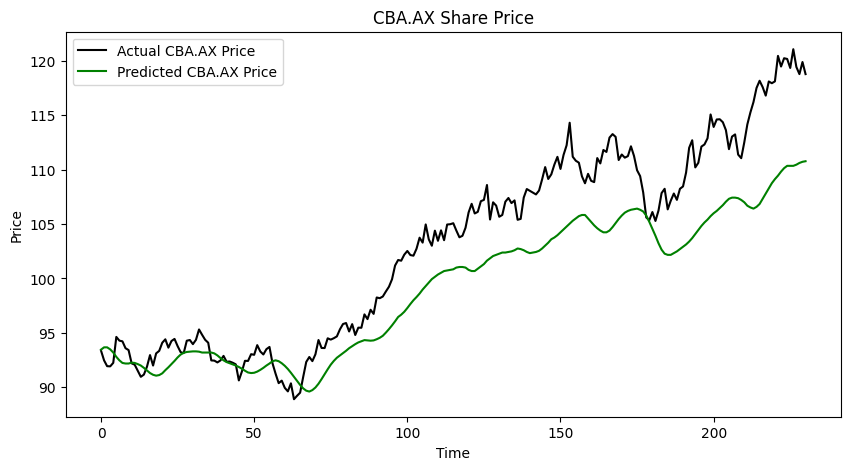

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicted next closing price: 110.87780144065619


In [29]:
## Compare actual and predicted prices
plt.figure(figsize=(10, 5))
plt.plot(actual_prices, color="black", label=f"Actual {COMPANY} Price")
plt.plot(predicted_prices, color="green", label=f"Predicted {COMPANY} Price")
plt.title(f"{COMPANY} Share Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

## Predict the next trading day

# This section uses the latest 60 days of input data to estimate the next closing price.
real_data = [model_inputs[len(model_inputs) - PREDICTION_DAYS:]]
real_data = np.array(real_data)

prediction_scaled = model.predict(real_data)

dummy = np.zeros((1, len(FEATURE_COLUMNS)))
dummy[0, target_index] = prediction_scaled[0, 0]

prediction = scaler.inverse_transform(dummy)[:, target_index]
print(f"Predicted next closing price: {prediction[0]}")

In [30]:
# Week 6: Visualization & Segmentation

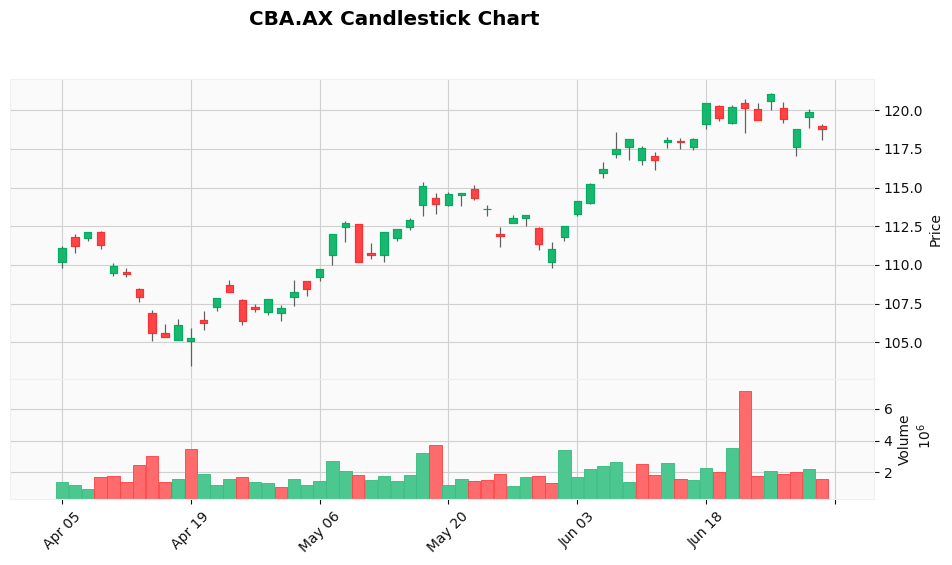

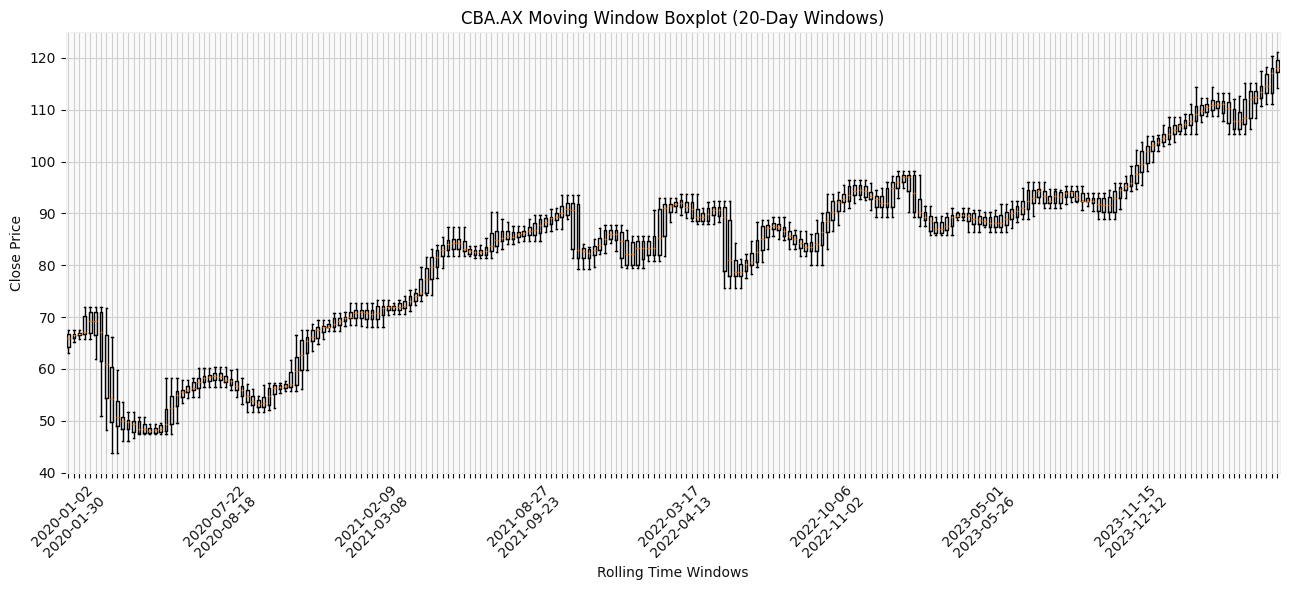

Saved: cba_candlestick_chart.png
Saved: cba_moving_boxplot.png


In [32]:
full_data = pd.concat([data, test_data])
full_data = full_data[~full_data.index.duplicated(keep='first')]

candlestick_file = plot_and_save_candlestick_chart(
    full_data,
    company=COMPANY,
    last_n_days=60,
    save_path='cba_candlestick_chart.png'
)

boxplot_file = plot_and_save_moving_window_boxplot(
    full_data,
    price_column='Close',
    window_size=20,
    step=5,
    company=COMPANY,
    save_path='cba_moving_boxplot.png'
)

print("Saved:", candlestick_file)
print("Saved:", boxplot_file)

# from IPython.display import Image, display

# display(Image(filename=candlestick_file))
# display(Image(filename=boxplot_file))